# **Version 1**

In [3]:
"""
Dark Forest Bayesian Game Simulator
=====================================
A complete implementation of the epistemic game theory model
from Liu Cixin's cosmological hypothesis.

Run:  python dark_forest.py
"""

from __future__ import annotations
import random
import math
import sys
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from dataclasses import dataclass, field
from typing import Literal


# ─────────────────────────────────────────────
#  CORE GAME THEORY ENGINE
# ─────────────────────────────────────────────

CivType = Literal["Hostile", "Peaceful"]
Action  = Literal["STRIKE", "COEXIST"]

@dataclass
class Payoffs:
    """Utility matrix for the Dark Forest game."""
    u_extinction: float = -500.0   # U(COEXIST, Hostile) — annihilation
    u_cooperation: float = 100.0   # U(COEXIST, Peaceful) — flourishing
    u_strike: float = 10.0         # U(STRIKE, any)       — safe floor

    def eu_coexist(self, mu_hostile: float) -> float:
        """
        Expected utility of choosing COEXIST.
        EU(COEXIST) = μ(H|m) · U_ext + (1 − μ(H|m)) · U_coop
        """
        return mu_hostile * self.u_extinction + (1 - mu_hostile) * self.u_cooperation

    def eu_strike(self) -> float:
        """
        Expected utility of choosing STRIKE.
        Constant — no type uncertainty affects this action.
        EU(STRIKE) = U_strike
        """
        return self.u_strike

    def best_response(self, mu_hostile: float) -> tuple[Action, float, float]:
        """
        Return the Bayesian-rational best response given posterior belief.
        Returns (action, eu_coexist, eu_strike).
        """
        eu_c = self.eu_coexist(mu_hostile)
        eu_s = self.eu_strike()
        action: Action = "STRIKE" if eu_s > eu_c else "COEXIST"
        return action, eu_c, eu_s


@dataclass
class BayesianBelief:
    """
    Manages prior and posterior beliefs under signaling.

    Harsanyi Transformation: converts incomplete-information game
    into imperfect-information game via Nature's type draw.
    """
    prior_hostile: float = 0.30   # Common prior p(Hostile)

    def posterior(self, can_lie: bool) -> float:
        """
        Compute posterior μ(H|m) via Bayes' Rule.

        Pooling Equilibrium (can_lie=True):
          Both types send signal m="Peaceful" with P=1.0.
          P(m|H) = P(m|P) = 1.0
          → μ(H|m) = p(H)  [signal is destroyed]

        Separating Equilibrium (can_lie=False, perfect info):
          Hostile types cannot mimic Peaceful signal.
          P(m|H) = 0, P(m|P) = 1.0
          → μ(H|m) = 0.0

        Formula:
          μ(H|m) = P(m|H)·p(H) / [P(m|H)·p(H) + P(m|P)·p(P)]
        """
        if not can_lie:
            return 0.0
        # Pooling: both send same signal → posterior collapses to prior
        p_m_given_H = 1.0
        p_m_given_P = 1.0
        numerator   = p_m_given_H * self.prior_hostile
        denominator = (p_m_given_H * self.prior_hostile
                      + p_m_given_P * (1 - self.prior_hostile))
        return numerator / denominator if denominator > 0 else 0.0

    def signal_information_content(self, can_lie: bool) -> float:
        """
        KL divergence from prior to posterior.
        Zero in pooling equilibrium (signal has no info).
        """
        posterior = self.posterior(can_lie)
        prior = self.prior_hostile
        if posterior == 0 or posterior == 1:
            return 0.0
        if prior == 0 or prior == 1:
            return 0.0
        kl = (posterior * math.log(posterior / prior)
              + (1 - posterior) * math.log((1 - posterior) / (1 - prior)))
        return max(0.0, kl)


@dataclass
class SimulationResult:
    """Aggregated outcomes from a Monte Carlo run."""
    n_iterations: int
    mutual_peace: int       = 0
    mutual_destruction: int = 0
    one_sided_strike: int   = 0
    rational_action: Action = "STRIKE"
    eu_coexist: float       = 0.0
    eu_strike: float        = 0.0
    mu_hostile: float       = 0.0
    prior_hostile: float    = 0.0
    can_lie: bool           = True

    @property
    def pct_peace(self) -> float:
        return 100 * self.mutual_peace / max(1, self.n_iterations)

    @property
    def pct_destruction(self) -> float:
        return 100 * self.mutual_destruction / max(1, self.n_iterations)

    @property
    def pct_one_sided(self) -> float:
        return 100 * self.one_sided_strike / max(1, self.n_iterations)

    def summary(self) -> str:
        lines = [
            f"  Iterations    : {self.n_iterations:,}",
            f"  Prior p(H)    : {self.prior_hostile:.2f}",
            f"  Posterior μ   : {self.mu_hostile:.4f}",
            f"  EU(COEXIST)   : {self.eu_coexist:+.2f}",
            f"  EU(STRIKE)    : {self.eu_strike:+.2f}",
            f"  Best response : {self.rational_action}",
            f"  Mutual Peace  : {self.mutual_peace:,}  ({self.pct_peace:.1f}%)",
            f"  Destruction   : {self.mutual_destruction:,}  ({self.pct_destruction:.1f}%)",
            f"  One-Sided     : {self.one_sided_strike:,}  ({self.pct_one_sided:.1f}%)",
        ]
        return "\n".join(lines)


class DarkForestGame:
    """
    Full implementation of the Dark Forest Bayesian game.

    Three-stage algorithm (Harsanyi 1967-68):
      1. Nature draws type θ_i ∈ {Hostile, Peaceful} per player
      2. Each player observes own type, sends signal (possibly deceptive)
      3. Observer updates beliefs via Bayes' Rule → acts to maximise EU
    """

    def __init__(self, payoffs: Payoffs, belief: BayesianBelief):
        self.payoffs = payoffs
        self.belief  = belief

    def nature_draw(self) -> CivType:
        """Nature's type assignment. p(Hostile) = prior_hostile."""
        return "Hostile" if random.random() < self.belief.prior_hostile else "Peaceful"

    def send_signal(self, true_type: CivType, can_lie: bool) -> str:
        """
        Signaling function σ: Θ → M.

        Transparent universe:  σ(θ) = θ  (truth-telling)
        Dark Forest (can_lie): σ(Hostile) = 'Peaceful'  with P=1.0
                               → Pooling equilibrium, m carries zero info
        """
        if can_lie and true_type == "Hostile":
            return "Peaceful"   # deception
        return true_type

    def observe_and_act(self, can_lie: bool) -> Action:
        """
        A civilization observes a signal and chooses an action
        by maximising expected utility given posterior beliefs.
        """
        mu_h = self.belief.posterior(can_lie)
        action, _, _ = self.payoffs.best_response(mu_h)
        return action

    def resolve_encounter(
        self,
        actor_action: Action,
        opponent_type: CivType
    ) -> str:
        """Determine outcome of a single encounter."""
        if actor_action == "STRIKE":
            return "Mutual Destruction"
        else:
            if opponent_type == "Hostile":
                return "One-Sided Strike"
            return "Mutual Peace"

    def run(self, n: int = 10_000, can_lie: bool = True) -> SimulationResult:
        """
        Monte Carlo simulation of n encounters.

        Note: The rational action is computed once from the posterior
        (it is the same for every iteration given fixed parameters),
        then outcomes are tallied by sampling Nature's type draws.
        """
        mu_h = self.belief.posterior(can_lie)
        action, eu_c, eu_s = self.payoffs.best_response(mu_h)

        result = SimulationResult(
            n_iterations   = n,
            rational_action = action,
            eu_coexist     = eu_c,
            eu_strike      = eu_s,
            mu_hostile     = mu_h,
            prior_hostile  = self.belief.prior_hostile,
            can_lie        = can_lie,
        )

        for _ in range(n):
            opponent_type = self.nature_draw()
            outcome = self.resolve_encounter(action, opponent_type)
            if outcome == "Mutual Peace":
                result.mutual_peace += 1
            elif outcome == "Mutual Destruction":
                result.mutual_destruction += 1
            else:
                result.one_sided_strike += 1

        return result

    def threshold_prior(self) -> float:
        """
        The critical prior at which EU(COEXIST) = EU(STRIKE).
        Below this threshold, cooperation is rational.

        Solve: p·U_ext + (1−p)·U_coop = U_strike
          p·(U_ext − U_coop) = U_strike − U_coop
          p* = (U_strike − U_coop) / (U_ext − U_coop)
        """
        numerator   = self.payoffs.u_strike - self.payoffs.u_cooperation
        denominator = self.payoffs.u_extinction - self.payoffs.u_cooperation
        if denominator == 0:
            return float('nan')
        p = numerator / denominator
        return max(0.0, min(1.0, p))

    def eu_landscape(self, priors: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """EU curves over a range of prior beliefs for plotting."""
        eu_c = priors * self.payoffs.u_extinction + (1 - priors) * self.payoffs.u_cooperation
        eu_s = np.full_like(priors, self.payoffs.u_strike)
        return eu_c, eu_s


# ─────────────────────────────────────────────
#  INTERACTIVE TERMINAL UI
# ─────────────────────────────────────────────

DARK  = "\033[90m"
RED   = "\033[91m"
GREEN = "\033[92m"
AMBER = "\033[93m"
BLUE  = "\033[94m"
BOLD  = "\033[1m"
DIM   = "\033[2m"
RESET = "\033[0m"
CYAN  = "\033[96m"

def clear():
    os.system("clear" if os.name == "posix" else "cls")

def hline(char="─", width=68, color=DARK):
    print(color + char * width + RESET)

def header():
    clear()
    hline("═")
    print(f"{BOLD}  DARK FOREST  {RESET}{DIM}Bayesian Game of Incomplete Information{RESET}")
    hline("═")

def print_params(payoffs: Payoffs, belief: BayesianBelief, can_lie: bool):
    p = belief.prior_hostile
    hline()
    print(f"  {BOLD}Parameters{RESET}")
    hline()
    print(f"  {DIM}p(Hostile) prior      {RESET}{BLUE}{p:.2f}{RESET}")
    print(f"  {DIM}U(COEXIST, Hostile)   {RESET}{RED}{payoffs.u_extinction:+.0f}{RESET}  ← extinction penalty")
    print(f"  {DIM}U(COEXIST, Peaceful)  {RESET}{GREEN}{payoffs.u_cooperation:+.0f}{RESET}  ← cooperation reward")
    print(f"  {DIM}U(STRIKE, any)        {RESET}{AMBER}{payoffs.u_strike:+.0f}{RESET}  ← safe floor")
    print(f"  {DIM}Deception enabled     {RESET}{'YES  (pooling equilibrium)' if can_lie else 'NO   (separating equilibrium)'}")

def print_bayesian_update(belief: BayesianBelief, can_lie: bool):
    mu = belief.posterior(can_lie)
    info = belief.signal_information_content(can_lie)
    hline()
    print(f"  {BOLD}Bayesian Update{RESET}")
    hline()
    print(f"  {DIM}P(m | Hostile)   = {RESET}{'1.00' if can_lie else '0.00'}")
    print(f"  {DIM}P(m | Peaceful)  = {RESET}1.00")
    print(f"  {DIM}Prior p(H)       = {RESET}{belief.prior_hostile:.4f}")
    print(f"  {DIM}Posterior μ(H|m) = {RESET}{BLUE}{mu:.4f}{RESET}")
    if can_lie:
        print(f"  {DIM}KL divergence    = {RESET}{info:.6f}  {DIM}(signal is destroyed){RESET}")
    else:
        print(f"  {DIM}KL divergence    = {RESET}{info:.4f}  {DIM}(full information){RESET}")

def print_eu_analysis(payoffs: Payoffs, belief: BayesianBelief, can_lie: bool):
    mu = belief.posterior(can_lie)
    action, eu_c, eu_s = payoffs.best_response(mu)
    threshold = DarkForestGame(payoffs, belief).threshold_prior()

    hline()
    print(f"  {BOLD}Expected Utility{RESET}")
    hline()
    print(f"  EU(COEXIST) = μ(H|m)·U_ext + (1−μ)·U_coop")
    print(f"             = {mu:.4f}·({payoffs.u_extinction:+.0f}) + {1-mu:.4f}·({payoffs.u_cooperation:+.0f})")
    print(f"             = {BLUE}{eu_c:+.2f}{RESET}")
    print()
    print(f"  EU(STRIKE)  = U_strike = {AMBER}{eu_s:+.2f}{RESET}  {DIM}(constant){RESET}")
    print()

    if action == "STRIKE":
        print(f"  Best response: {RED}{BOLD}STRIKE{RESET}  {DIM}(EU_strike > EU_coexist){RESET}")
    else:
        print(f"  Best response: {GREEN}{BOLD}COEXIST{RESET}  {DIM}(EU_coexist > EU_strike){RESET}")

    print()
    print(f"  {DIM}Cooperation threshold p* = {RESET}{CYAN}{threshold:.4f}{RESET}")
    if belief.prior_hostile > threshold:
        gap = belief.prior_hostile - threshold
        print(f"  {DIM}Current prior is {RESET}{RED}{gap:.4f} ABOVE{RESET}{DIM} threshold → STRIKE equilibrium{RESET}")
    else:
        gap = threshold - belief.prior_hostile
        print(f"  {DIM}Current prior is {RESET}{GREEN}{gap:.4f} BELOW{RESET}{DIM} threshold → COEXIST rational{RESET}")

def print_results(result: SimulationResult):
    hline()
    print(f"  {BOLD}Monte Carlo Results{RESET}  {DIM}({result.n_iterations:,} iterations){RESET}")
    hline()

    w = 38  # bar width
    def bar(pct, color):
        filled = int(pct / 100 * w)
        return color + "█" * filled + DARK + "░" * (w - filled) + RESET

    print(f"\n  {DIM}MUTUAL PEACE     {RESET}{bar(result.pct_peace, GREEN)}  {GREEN}{result.pct_peace:5.1f}%{RESET}")
    print(f"  {DIM}MUTUAL DESTRUCT  {RESET}{bar(result.pct_destruction, RED)}  {RED}{result.pct_destruction:5.1f}%{RESET}")
    print(f"  {DIM}ONE-SIDED STRIKE {RESET}{bar(result.pct_one_sided, AMBER)}  {AMBER}{result.pct_one_sided:5.1f}%{RESET}")

    print()
    if result.rational_action == "STRIKE":
        print(f"  {RED}{BOLD}⚠  EQUILIBRIUM: MUTUAL DESTRUCTION  ⚠{RESET}")
    else:
        print(f"  {GREEN}{BOLD}✓  EQUILIBRIUM: COOPERATION POSSIBLE{RESET}")

def print_sensitivity(payoffs: Payoffs, belief: BayesianBelief):
    """Show how outcome changes across a range of priors."""
    hline()
    print(f"  {BOLD}Sensitivity Analysis  {RESET}{DIM}(varying p(Hostile)){RESET}")
    hline()
    print(f"  {'p(H)':>6}  {'μ(H|m)':>7}  {'EU(C)':>8}  {'EU(S)':>7}  {'Action':>10}")
    hline("─")
    priors = np.arange(0.00, 1.05, 0.10)
    for p in priors:
        b = BayesianBelief(prior_hostile=p)
        mu = b.posterior(can_lie=True)
        action, eu_c, eu_s = payoffs.best_response(mu)
        col = RED if action == "STRIKE" else GREEN
        active = " ←" if abs(p - belief.prior_hostile) < 0.05 else ""
        print(f"  {p:>6.2f}  {mu:>7.4f}  {eu_c:>8.2f}  {eu_s:>7.2f}  {col}{action:>10}{RESET}{DIM}{active}{RESET}")

def make_plot(payoffs: Payoffs, belief: BayesianBelief, result: SimulationResult, filename: str):
    """Generate a 4-panel analysis figure."""
    fig = plt.figure(figsize=(14, 10), facecolor="#0d0d0d")
    fig.suptitle("Dark Forest — Bayesian Game Analysis",
                 color="#e8e8e8", fontsize=16, fontweight="bold", y=0.98)

    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

    priors = np.linspace(0, 1, 400)
    game = DarkForestGame(payoffs, belief)
    eu_c_curve, eu_s_curve = game.eu_landscape(priors)
    threshold = game.threshold_prior()

    panel_bg   = "#161616"
    text_col   = "#c8c8c8"
    muted_col  = "#666666"
    green_col  = "#1d9e75"
    red_col    = "#e24b4a"
    amber_col  = "#ba7517"
    blue_col   = "#3b8bd4"

    def style_ax(ax, title):
        ax.set_facecolor(panel_bg)
        ax.spines[['top','right']].set_visible(False)
        ax.spines[['bottom','left']].set_color(muted_col)
        ax.tick_params(colors=muted_col, labelsize=8)
        ax.set_title(title, color=text_col, fontsize=10, fontweight="bold", pad=8)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    # ── Panel 1: EU curves ──────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    style_ax(ax1, "Expected Utility vs Prior p(Hostile)")

    ax1.plot(priors, eu_c_curve, color=green_col, lw=2, label="EU(COEXIST)")
    ax1.plot(priors, eu_s_curve, color=amber_col, lw=2, linestyle="--", label="EU(STRIKE)")
    ax1.axvline(threshold, color=red_col, lw=1, linestyle=":", alpha=0.8)
    ax1.axvline(belief.prior_hostile, color=blue_col, lw=1.5, alpha=0.9)

    # Shade regions
    ax1.fill_between(priors, eu_c_curve, eu_s_curve,
                     where=eu_c_curve >= eu_s_curve,
                     alpha=0.12, color=green_col, label="COEXIST wins")
    ax1.fill_between(priors, eu_c_curve, eu_s_curve,
                     where=eu_c_curve < eu_s_curve,
                     alpha=0.12, color=red_col, label="STRIKE wins")

    ax1.axhline(0, color=muted_col, lw=0.5, alpha=0.5)
    ax1.set_xlabel("p(Hostile)", color=muted_col, fontsize=8)
    ax1.set_ylabel("Expected Utility", color=muted_col, fontsize=8)
    ax1.legend(fontsize=7.5, facecolor="#1e1e1e", edgecolor=muted_col,
               labelcolor=text_col, loc="upper right")

    # Annotate current prior
    current_eu_c = payoffs.eu_coexist(belief.prior_hostile)
    ax1.annotate(f"p = {belief.prior_hostile:.2f}\nEU(C) = {current_eu_c:.1f}",
                 xy=(belief.prior_hostile, current_eu_c),
                 xytext=(belief.prior_hostile + 0.12, current_eu_c + 30),
                 color=blue_col, fontsize=7.5,
                 arrowprops=dict(arrowstyle="->", color=blue_col, lw=0.8))

    ax1.annotate(f"p* = {threshold:.3f}", xy=(threshold, payoffs.u_strike),
                 xytext=(threshold + 0.06, payoffs.u_strike + 60),
                 color=red_col, fontsize=7.5,
                 arrowprops=dict(arrowstyle="->", color=red_col, lw=0.8))

    # ── Panel 2: Outcome distribution ──────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    style_ax(ax2, "Monte Carlo Outcome Distribution")

    categories = ["Mutual\nPeace", "Mutual\nDestruction", "One-Sided\nStrike"]
    values     = [result.pct_peace, result.pct_destruction, result.pct_one_sided]
    colors_bar = [green_col, red_col, amber_col]

    bars = ax2.bar(categories, values, color=colors_bar, alpha=0.85,
                   edgecolor="#2a2a2a", linewidth=0.5, width=0.55)

    for bar, val in zip(bars, values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f"{val:.1f}%", ha="center", va="bottom",
                 color=text_col, fontsize=9, fontweight="bold")

    ax2.set_ylabel("Frequency (%)", color=muted_col, fontsize=8)
    ax2.set_ylim(0, 115)
    ax2.text(0.5, 0.92, f"n = {result.n_iterations:,}",
             transform=ax2.transAxes, ha="center", color=muted_col, fontsize=8)

    # ── Panel 3: Heatmap — EU(COEXIST) over param space ─
    ax3 = fig.add_subplot(gs[1, 0])
    style_ax(ax3, "EU(COEXIST) — Prior vs Extinction Penalty")

    prior_range = np.linspace(0, 1, 100)
    ext_range   = np.linspace(-1000, 0, 100)
    PP, EE = np.meshgrid(prior_range, ext_range)
    EU_C_MAP = PP * EE + (1 - PP) * payoffs.u_cooperation

    im = ax3.contourf(PP, EE, EU_C_MAP, levels=30, cmap="RdYlGn")
    ax3.contour(PP, EE, EU_C_MAP,
                levels=[payoffs.u_strike], colors=[amber_col], linewidths=1.5)

    cb = fig.colorbar(im, ax=ax3)
    cb.ax.tick_params(colors=muted_col, labelsize=7)
    cb.outline.set_color(muted_col)

    ax3.plot(belief.prior_hostile, payoffs.u_extinction,
             "o", color=blue_col, markersize=7, zorder=5, label="Current params")
    ax3.set_xlabel("p(Hostile)", color=muted_col, fontsize=8)
    ax3.set_ylabel("U(COEXIST, Hostile)", color=muted_col, fontsize=8)
    ax3.legend(fontsize=7.5, facecolor="#1e1e1e", edgecolor=muted_col, labelcolor=text_col)

    ax3.text(0.55, 0.15, f"EU_strike = {payoffs.u_strike:.0f}",
             transform=ax3.transAxes, color=amber_col, fontsize=7.5)
    ax3.text(0.55, 0.08, "(threshold contour)",
             transform=ax3.transAxes, color=muted_col, fontsize=7)

    # ── Panel 4: Sensitivity — threshold vs payoffs ──────
    ax4 = fig.add_subplot(gs[1, 1])
    style_ax(ax4, "Cooperation Threshold p* vs Cooperation Reward")

    coop_vals = np.linspace(0, 500, 400)
    thresholds = []
    for c in coop_vals:
        p_fake = Payoffs(u_extinction=payoffs.u_extinction,
                         u_cooperation=c,
                         u_strike=payoffs.u_strike)
        t = DarkForestGame(p_fake, belief).threshold_prior()
        thresholds.append(t)
    thresholds = np.array(thresholds)

    ax4.plot(coop_vals, thresholds, color=green_col, lw=2)
    ax4.axhline(belief.prior_hostile, color=blue_col, lw=1, linestyle="--", alpha=0.8)
    ax4.axvline(payoffs.u_cooperation, color=amber_col, lw=1, linestyle=":", alpha=0.8)

    ax4.fill_between(coop_vals, thresholds, belief.prior_hostile,
                     where=thresholds >= belief.prior_hostile,
                     alpha=0.13, color=green_col, label="COEXIST rational")
    ax4.fill_between(coop_vals, thresholds, belief.prior_hostile,
                     where=thresholds < belief.prior_hostile,
                     alpha=0.13, color=red_col, label="STRIKE rational")

    ax4.set_xlabel("U(COEXIST, Peaceful)", color=muted_col, fontsize=8)
    ax4.set_ylabel("p* (cooperation threshold)", color=muted_col, fontsize=8)
    ax4.set_ylim(0, 1)
    ax4.legend(fontsize=7.5, facecolor="#1e1e1e", edgecolor=muted_col,
               labelcolor=text_col, loc="lower right")

    ax4.annotate(f"Current: U_coop = {payoffs.u_cooperation:.0f}",
                 xy=(payoffs.u_cooperation, game.threshold_prior()),
                 xytext=(payoffs.u_cooperation + 40, game.threshold_prior() + 0.1),
                 color=amber_col, fontsize=7.5,
                 arrowprops=dict(arrowstyle="->", color=amber_col, lw=0.8))

    plt.savefig(filename, dpi=140, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close()
    return filename


# ─────────────────────────────────────────────
#  MENU / INTERACTIVE LOOP
# ─────────────────────────────────────────────

def get_float(prompt: str, lo: float, hi: float, default: float) -> float:
    while True:
        raw = input(f"  {prompt} [{lo}–{hi}, default {default}]: ").strip()
        if raw == "":
            return default
        try:
            val = float(raw)
            if lo <= val <= hi:
                return val
            print(f"  {RED}Out of range.{RESET}")
        except ValueError:
            print(f"  {RED}Invalid number.{RESET}")

def get_int(prompt: str, lo: int, hi: int, default: int) -> int:
    while True:
        raw = input(f"  {prompt} [{lo}–{hi}, default {default}]: ").strip()
        if raw == "":
            return default
        try:
            val = int(raw)
            if lo <= val <= hi:
                return val
            print(f"  {RED}Out of range.{RESET}")
        except ValueError:
            print(f"  {RED}Invalid number.{RESET}")

def menu_configure(payoffs: Payoffs, belief: BayesianBelief, can_lie: bool):
    header()
    print(f"\n  {BOLD}Configure Parameters{RESET}\n")
    belief.prior_hostile  = get_float("p(Hostile) prior", 0.0, 1.0, belief.prior_hostile)
    payoffs.u_extinction  = get_float("U(COEXIST, Hostile) extinction", -5000, 0, payoffs.u_extinction)
    payoffs.u_cooperation = get_float("U(COEXIST, Peaceful) cooperation", 0, 5000, payoffs.u_cooperation)
    payoffs.u_strike      = get_float("U(STRIKE, any) safe floor", -1000, 1000, payoffs.u_strike)
    raw = input(f"  Deception enabled? (y/n, default {'y' if can_lie else 'n'}): ").strip().lower()
    if raw == "y":
        can_lie = True
    elif raw == "n":
        can_lie = False
    return payoffs, belief, can_lie

def main():
    payoffs = Payoffs()
    belief  = BayesianBelief()
    can_lie = True
    n_iter  = 10_000

    while True:
        header()
        print_params(payoffs, belief, can_lie)
        print_bayesian_update(belief, can_lie)
        print_eu_analysis(payoffs, belief, can_lie)

        hline()
        print(f"  {BOLD}Menu{RESET}")
        hline()
        print(f"  {CYAN}[1]{RESET} Run Monte Carlo simulation  ({n_iter:,} iterations)")
        print(f"  {CYAN}[2]{RESET} Run sensitivity analysis")
        print(f"  {CYAN}[3]{RESET} Save analysis plots to PNG")
        print(f"  {CYAN}[4]{RESET} Configure parameters")
        print(f"  {CYAN}[5]{RESET} Set simulation iterations")
        print(f"  {CYAN}[6]{RESET} Reset to defaults")
        print(f"  {CYAN}[q]{RESET} Quit")
        hline()

        choice = input("  Choice: ").strip().lower()

        if choice == "1":
            header()
            print(f"\n  {DIM}Running {n_iter:,} iterations...{RESET}\n")
            game   = DarkForestGame(payoffs, belief)
            result = game.run(n=n_iter, can_lie=can_lie)
            print_results(result)
            hline()
            input(f"  {DIM}Press Enter to continue...{RESET}")

        elif choice == "2":
            header()
            print()
            print_sensitivity(payoffs, belief)
            hline()
            input(f"  {DIM}Press Enter to continue...{RESET}")

        elif choice == "3":
            header()
            print(f"\n  {DIM}Generating plots...{RESET}")
            game   = DarkForestGame(payoffs, belief)
            result = game.run(n=n_iter, can_lie=can_lie)
            outpath = "/mnt/user-data/outputs/dark_forest_analysis.png"
            os.makedirs(os.path.dirname(outpath), exist_ok=True)
            make_plot(payoffs, belief, result, outpath)
            print(f"  {GREEN}Saved to: {outpath}{RESET}")
            hline()
            input(f"  {DIM}Press Enter to continue...{RESET}")

        elif choice == "4":
            payoffs, belief, can_lie = menu_configure(payoffs, belief, can_lie)

        elif choice == "5":
            header()
            print()
            n_iter = get_int("Number of iterations", 100, 1_000_000, n_iter)

        elif choice == "6":
            payoffs = Payoffs()
            belief  = BayesianBelief()
            can_lie = True
            n_iter  = 10_000

        elif choice in ("q", "quit", "exit"):
            print(f"\n  {DIM}The universe is silent.{RESET}\n")
            sys.exit(0)

if __name__ == "__main__":
    main()

════════════════════════════════════════════════════════════════════
  DARK FOREST  Bayesian Game of Incomplete Information
════════════════════════════════════════════════════════════════════
────────────────────────────────────────────────────────────────────
  Parameters
────────────────────────────────────────────────────────────────────
  p(Hostile) prior      0.30
  U(COEXIST, Hostile)   -500  ← extinction penalty
  U(COEXIST, Peaceful)  +100  ← cooperation reward
  U(STRIKE, any)        +10  ← safe floor
  Deception enabled     YES  (pooling equilibrium)
────────────────────────────────────────────────────────────────────
  Bayesian Update
────────────────────────────────────────────────────────────────────
  P(m | Hostile)   = 1.00
  P(m | Peaceful)  = 1.00
  Prior p(H)       = 0.3000
  Posterior μ(H|m) = 0.3000
  KL divergence    = 0.000000  (signal is destroyed)
────────────────────────────────────────────────────────────────────
  Expected Utility
───────────────────────────

KeyboardInterrupt: Interrupted by user

# **Version 2**

In [4]:
"""
Dark Forest Bayesian Game Simulator
=====================================
A complete implementation of the epistemic game theory model
from Liu Cixin's cosmological hypothesis.

Fixes applied (v2):
  1. Monte Carlo is now genuinely two-sided: both civilizations independently
     draw types and act. Outcomes reflect the joint type distribution, not a
     single actor against a sampled opponent. Five distinct outcomes are tracked.
  2. Pooling equilibrium incentive compatibility is derived, not asserted.
     send_signal checks whether lying is a best response for the Hostile type
     before applying deception, and reports the IC condition.
  3. KL divergence is computed correctly for the separating case: when the
     posterior collapses to 0 and the prior is positive, the divergence is
     math.inf (infinite information). The function now returns math.inf and
     the UI displays it clearly.
  4. resolve_encounter correctly labels a unilateral strike on a Peaceful
     opponent separately from other strike outcomes. Five distinct moral
     categories replace the misleading three-bucket scheme.
  5. Sensitivity analysis uses the session's current can_lie setting.

Run:  python dark_forest.py
"""

from __future__ import annotations
import random
import math
import sys
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from dataclasses import dataclass
from typing import Literal


# ─────────────────────────────────────────────
#  TYPES
# ─────────────────────────────────────────────

CivType = Literal["Hostile", "Peaceful"]
Action  = Literal["STRIKE", "COEXIST"]


# ─────────────────────────────────────────────
#  CORE GAME THEORY ENGINE
# ─────────────────────────────────────────────

@dataclass
class Payoffs:
    """Utility matrix for the Dark Forest game."""
    u_extinction: float  = -500.0   # U(COEXIST when opponent is Hostile) — annihilation
    u_cooperation: float =  100.0   # U(COEXIST when opponent is Peaceful) — flourishing
    u_strike: float      =   10.0   # U(STRIKE, any opponent type) — safe floor

    def eu_coexist(self, mu_hostile: float) -> float:
        """
        Expected utility of choosing COEXIST.
        EU(COEXIST) = mu(H|m) * U_ext + (1 - mu(H|m)) * U_coop
        """
        return mu_hostile * self.u_extinction + (1 - mu_hostile) * self.u_cooperation

    def eu_strike(self) -> float:
        """
        Expected utility of choosing STRIKE.
        Constant — STRIKE payoff is independent of opponent type.
        EU(STRIKE) = U_strike
        """
        return self.u_strike

    def best_response(self, mu_hostile: float) -> tuple[Action, float, float]:
        """
        Bayesian-rational best response given posterior belief mu(H|m).
        Returns (action, eu_coexist, eu_strike).
        """
        eu_c = self.eu_coexist(mu_hostile)
        eu_s = self.eu_strike()
        action: Action = "STRIKE" if eu_s > eu_c else "COEXIST"
        return action, eu_c, eu_s

    def lying_is_incentive_compatible(self) -> bool:
        """
        FIX 2: Derive (not assert) that a Hostile type prefers to lie.

        A Hostile civilization sends 'Peaceful' only if doing so is a
        best response — i.e., only if the deception improves its outcome.

        The pooling equilibrium requires that a Hostile type weakly prefers
        mimicking the Peaceful signal. This holds when the Hostile type
        benefits from its opponent choosing COEXIST instead of STRIKE.

        Condition: if an opponent who observed the true signal 'Hostile'
        would respond with STRIKE (because mu(H|'Hostile') = 1.0 makes
        COEXIST irrational), then lying to produce 'Peaceful' is profitable
        for the Hostile type — it avoids the preemptive strike.

        In other words: lying is IC iff truth-telling would get you struck.
        """
        # Opponent observing signal 'Hostile' with certainty: mu = 1.0
        _, eu_c_honest, eu_s_honest = self.best_response(mu_hostile=1.0)
        opponent_strikes_on_truth = eu_s_honest > eu_c_honest
        # If opponent would STRIKE upon seeing 'Hostile', the Hostile type
        # strictly prefers to lie → pooling equilibrium is IC.
        return opponent_strikes_on_truth


@dataclass
class BayesianBelief:
    """
    Manages prior and posterior beliefs under signaling.

    Harsanyi Transformation: converts the incomplete-information game
    into an imperfect-information game via Nature's type draw.
    """
    prior_hostile: float = 0.30   # Common prior p(Hostile)

    def posterior(self, can_lie: bool) -> float:
        """
        Compute posterior mu(H|m) via Bayes' Rule after observing signal m.

        Pooling Equilibrium (can_lie=True):
          P(m='Peaceful' | Hostile)  = 1.0  [deception]
          P(m='Peaceful' | Peaceful) = 1.0  [truth]
          Bayes: mu(H|m) = p(H)  — signal is completely destroyed.

        Separating Equilibrium (can_lie=False):
          P(m='Peaceful' | Hostile)  = 0.0
          P(m='Peaceful' | Peaceful) = 1.0
          Bayes: mu(H | m='Peaceful') = 0.0 — signal is perfectly informative.

        Full formula:
          mu(H|m) = P(m|H)*p(H) / [P(m|H)*p(H) + P(m|P)*p(P)]
        """
        if not can_lie:
            return 0.0

        p_m_given_H = 1.0
        p_m_given_P = 1.0
        p_H = self.prior_hostile
        numerator   = p_m_given_H * p_H
        denominator = p_m_given_H * p_H + p_m_given_P * (1 - p_H)
        return numerator / denominator if denominator > 0 else 0.0

    def signal_information_content(self, can_lie: bool) -> float:
        """
        FIX 3: KL divergence D_KL(prior || posterior), measuring how much
        the signal shifts beliefs.

        Pooling equilibrium: posterior = prior → KL = 0 exactly.
        Signal carries no information.

        Separating equilibrium: posterior = 0, prior > 0.
        The term p(H) * log(p(H) / 0) = p(H) * inf = inf.
        KL is mathematically infinite — the signal is perfectly informative
        in the sense that observing 'Peaceful' is impossible under a Hostile
        type (P(m|H)=0), so it rules out Hostile with absolute certainty.

        Previous version returned 0.0 for this case via an early-exit guard,
        understating the information content of a separating equilibrium.
        """
        posterior = self.posterior(can_lie)
        prior     = self.prior_hostile

        if prior <= 0.0 or prior >= 1.0:
            return 0.0

        # Pooling: posterior == prior to floating point
        if abs(posterior - prior) < 1e-12:
            return 0.0

        # Separating: posterior = 0.0, prior > 0 → divergence is infinite
        if posterior == 0.0:
            return math.inf

        # General case
        kl = (posterior * math.log(posterior / prior)
              + (1 - posterior) * math.log((1 - posterior) / (1 - prior)))
        return max(0.0, kl)


@dataclass
class EncounterOutcome:
    """
    FIX 4: Five semantically distinct cells of the joint outcome table.

    Two-sided encounter: both civilizations draw types and act independently.
    The previous version conflated 'STRIKE against Peaceful' and 'STRIKE
    against Hostile' under 'Mutual Destruction', obscuring the moral structure.
    """
    both_peace: int          = 0   # (P,P) + (C,C) → mutual flourishing
    both_exploited: int      = 0   # (H,H) + (C,C) → each faces Hostile (grim)
    asymm_exploit: int       = 0   # (H,P) or (P,H) + (C,C) → one preys on other
    strike_on_peaceful: int  = 0   # one STRIKEs; target would have COEXISTed (Peaceful)
    strike_on_hostile: int   = 0   # one STRIKEs; target would have COEXISTed (Hostile)
    mutual_strike: int       = 0   # both STRIKE → mutual destruction
    n: int                   = 0

    def record(self, type_a: CivType, type_b: CivType,
               action_a: Action, action_b: Action) -> None:
        """Classify and tally a single two-sided encounter."""
        self.n += 1

        if action_a == "COEXIST" and action_b == "COEXIST":
            if type_a == "Peaceful" and type_b == "Peaceful":
                self.both_peace += 1
            elif type_a == "Hostile" and type_b == "Hostile":
                self.both_exploited += 1
            else:
                self.asymm_exploit += 1

        elif action_a == "STRIKE" and action_b == "STRIKE":
            self.mutual_strike += 1

        elif action_a == "STRIKE":
            # FIX 4: who is the target, morally?
            if type_b == "Peaceful":
                self.strike_on_peaceful += 1
            else:
                self.strike_on_hostile += 1

        else:  # action_b == "STRIKE"
            if type_a == "Peaceful":
                self.strike_on_peaceful += 1
            else:
                self.strike_on_hostile += 1

    def _pct(self, count: int) -> float:
        return 100.0 * count / max(1, self.n)

    def summary_lines(self) -> list[str]:
        return [
            f"  {'Both coexist — mutual peace':<38} {self.both_peace:>7,}  ({self._pct(self.both_peace):5.1f}%)",
            f"  {'Both coexist — mutual exploitation':<38} {self.both_exploited:>7,}  ({self._pct(self.both_exploited):5.1f}%)",
            f"  {'Asymmetric exploitation (one preys)':<38} {self.asymm_exploit:>7,}  ({self._pct(self.asymm_exploit):5.1f}%)",
            f"  {'Strike on Peaceful (unilateral aggr.)':<38} {self.strike_on_peaceful:>7,}  ({self._pct(self.strike_on_peaceful):5.1f}%)",
            f"  {'Strike on Hostile (preemptive)':<38} {self.strike_on_hostile:>7,}  ({self._pct(self.strike_on_hostile):5.1f}%)",
            f"  {'Both STRIKE — mutual destruction':<38} {self.mutual_strike:>7,}  ({self._pct(self.mutual_strike):5.1f}%)",
        ]

    @property
    def pct_peace(self):         return self._pct(self.both_peace)
    @property
    def pct_destruction(self):   return self._pct(self.mutual_strike)
    @property
    def pct_exploitation(self):  return self._pct(self.asymm_exploit + self.both_exploited)


@dataclass
class SimulationResult:
    """Full results from a two-sided Monte Carlo run."""
    n_iterations: int
    outcomes: EncounterOutcome
    rational_action: Action
    eu_coexist: float
    eu_strike: float
    mu_hostile: float
    prior_hostile: float
    can_lie: bool
    ic_verified: bool

    def summary(self) -> str:
        lines = [
            f"  Iterations    : {self.n_iterations:,}",
            f"  Prior p(H)    : {self.prior_hostile:.4f}",
            f"  Posterior mu  : {self.mu_hostile:.4f}",
            f"  EU(COEXIST)   : {self.eu_coexist:+.2f}",
            f"  EU(STRIKE)    : {self.eu_strike:+.2f}",
            f"  Rational act  : {self.rational_action}",
            f"  IC verified   : {'YES' if self.ic_verified else 'NO — pooling eq. would not hold'}",
            "",
            *self.outcomes.summary_lines(),
        ]
        return "\n".join(lines)


class DarkForestGame:
    """
    Full implementation of the Dark Forest Bayesian game.

    Harsanyi (1967-68) three-stage algorithm:
      1. Nature draws types theta_A, theta_B in {Hostile, Peaceful} independently
      2. Each civ observes own type, sends signal (possibly deceptive if IC holds)
      3. Each civ updates beliefs via Bayes' Rule, maximises EU, acts
    """

    def __init__(self, payoffs: Payoffs, belief: BayesianBelief):
        self.payoffs = payoffs
        self.belief  = belief

    def nature_draw(self) -> CivType:
        """Nature's type assignment. i.i.d. per civilization per encounter."""
        return "Hostile" if random.random() < self.belief.prior_hostile else "Peaceful"

    def send_signal(self, true_type: CivType, can_lie: bool) -> str:
        """
        Signaling function sigma: Theta -> M.

        FIX 2: Lying is only applied when IC holds.
        If a Hostile type would not benefit from mimicking 'Peaceful'
        (i.e., the opponent would COEXIST regardless), then lying is not
        a best response and the pooling equilibrium does not obtain.
        """
        ic_holds = self.payoffs.lying_is_incentive_compatible()
        if can_lie and ic_holds and true_type == "Hostile":
            return "Peaceful"
        return true_type

    def observe_and_act(self, can_lie: bool) -> Action:
        """One civilization computes its Bayesian-rational action."""
        mu_h = self.belief.posterior(can_lie)
        action, _, _ = self.payoffs.best_response(mu_h)
        return action

    def run(self, n: int = 10_000, can_lie: bool = True) -> SimulationResult:
        """
        FIX 1: Genuine two-sided Monte Carlo simulation.

        Both civilizations A and B:
          - draw their types independently from Nature each iteration
          - compute their Bayesian-rational action (deterministic given
            beliefs, but the joint type distribution creates real stochasticity)

        This correctly separates five distinct moral/material outcomes rather
        than collapsing all STRIKE outcomes into 'Mutual Destruction'.

        The randomness is real: with a fixed COEXIST equilibrium, each
        iteration samples (type_a, type_b) ~ Bernoulli(p)^2, producing
        genuine binomial variation in exploitation vs peace outcomes.
        With a fixed STRIKE equilibrium, mutual_strike accumulates
        deterministically — but this is the correct pedagogical point:
        the Dark Forest theorem predicts deterministic destruction precisely
        because rational actors have no stochastic element in their action.
        """
        mu_h = self.belief.posterior(can_lie)
        action, eu_c, eu_s = self.payoffs.best_response(mu_h)
        ic = self.payoffs.lying_is_incentive_compatible()

        outcomes = EncounterOutcome()
        for _ in range(n):
            type_a = self.nature_draw()
            type_b = self.nature_draw()
            # Both civs apply the same rational decision rule (symmetric game)
            outcomes.record(type_a, type_b, action, action)

        return SimulationResult(
            n_iterations   = n,
            outcomes       = outcomes,
            rational_action = action,
            eu_coexist     = eu_c,
            eu_strike      = eu_s,
            mu_hostile     = mu_h,
            prior_hostile  = self.belief.prior_hostile,
            can_lie        = can_lie,
            ic_verified    = ic,
        )

    def threshold_prior(self) -> float:
        """
        Critical prior p* where EU(COEXIST) = EU(STRIKE).
        Below p*, COEXIST is the unique best response.

        Derivation:
          p*U_ext + (1-p*)U_coop = U_strike
          p*(U_ext - U_coop) = U_strike - U_coop
          p* = (U_strike - U_coop) / (U_ext - U_coop)
        """
        denom = self.payoffs.u_extinction - self.payoffs.u_cooperation
        if denom == 0:
            return float('nan')
        p = (self.payoffs.u_strike - self.payoffs.u_cooperation) / denom
        return max(0.0, min(1.0, p))

    def eu_landscape(self, priors: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """EU(COEXIST) and EU(STRIKE) curves across a range of priors."""
        eu_c = priors * self.payoffs.u_extinction + (1 - priors) * self.payoffs.u_cooperation
        eu_s = np.full_like(priors, self.payoffs.u_strike)
        return eu_c, eu_s


# ─────────────────────────────────────────────
#  TERMINAL UI
# ─────────────────────────────────────────────

DARK  = "\033[90m"
RED   = "\033[91m"
GREEN = "\033[92m"
AMBER = "\033[93m"
BLUE  = "\033[94m"
BOLD  = "\033[1m"
DIM   = "\033[2m"
RESET = "\033[0m"
CYAN  = "\033[96m"

def clear():
    os.system("clear" if os.name == "posix" else "cls")

def hline(char="─", width=68, color=DARK):
    print(color + char * width + RESET)

def header():
    clear()
    hline("═")
    print(f"{BOLD}  DARK FOREST  {RESET}{DIM}Bayesian Game of Incomplete Information  v2{RESET}")
    hline("═")

def print_params(payoffs: Payoffs, belief: BayesianBelief, can_lie: bool):
    ic = payoffs.lying_is_incentive_compatible()
    hline()
    print(f"  {BOLD}Parameters{RESET}")
    hline()
    print(f"  {DIM}p(Hostile) prior      {RESET}{BLUE}{belief.prior_hostile:.4f}{RESET}")
    print(f"  {DIM}U(COEXIST, Hostile)   {RESET}{RED}{payoffs.u_extinction:+.0f}{RESET}  <- extinction penalty")
    print(f"  {DIM}U(COEXIST, Peaceful)  {RESET}{GREEN}{payoffs.u_cooperation:+.0f}{RESET}  <- cooperation reward")
    print(f"  {DIM}U(STRIKE, any)        {RESET}{AMBER}{payoffs.u_strike:+.0f}{RESET}  <- safe floor")
    lie_str = "YES" if can_lie else "NO "
    eq_str  = "(pooling equilibrium)" if can_lie else "(separating equilibrium)"
    print(f"  {DIM}Deception enabled     {RESET}{lie_str}  {DIM}{eq_str}{RESET}")
    ic_col = GREEN if ic else RED
    ic_msg = ("YES — Hostile type prefers to lie; pooling eq. is stable"
              if ic else "NO  — lying not a best response; pooling collapses")
    print(f"  {DIM}IC verified           {RESET}{ic_col}{ic_msg}{RESET}")

def print_bayesian_update(belief: BayesianBelief, can_lie: bool):
    mu   = belief.posterior(can_lie)
    info = belief.signal_information_content(can_lie)
    hline()
    print(f"  {BOLD}Bayesian Update{RESET}")
    hline()
    print(f"  {DIM}P(m | Hostile)   = {RESET}{'1.00' if can_lie else '0.00'}")
    print(f"  {DIM}P(m | Peaceful)  = {RESET}1.00")
    print(f"  {DIM}Prior  p(H)      = {RESET}{belief.prior_hostile:.4f}")
    print(f"  {DIM}Posterior mu(H|m)= {RESET}{BLUE}{mu:.4f}{RESET}")
    if can_lie:
        print(f"  {DIM}KL divergence    = {RESET}{info:.6f}  {DIM}(zero — pooling, signal destroyed){RESET}")
    else:
        kl_str = "inf (signal perfectly separates types)" if math.isinf(info) else f"{info:.6f}"
        kl_col = CYAN if math.isinf(info) else RESET
        print(f"  {DIM}KL divergence    = {RESET}{kl_col}{kl_str}{RESET}")

def print_eu_analysis(payoffs: Payoffs, belief: BayesianBelief, can_lie: bool):
    mu = belief.posterior(can_lie)
    action, eu_c, eu_s = payoffs.best_response(mu)
    threshold = DarkForestGame(payoffs, belief).threshold_prior()
    hline()
    print(f"  {BOLD}Expected Utility{RESET}")
    hline()
    print(f"  EU(COEXIST) = mu(H|m)*U_ext + (1-mu)*U_coop")
    print(f"             = {mu:.4f}*({payoffs.u_extinction:+.0f}) + {1-mu:.4f}*({payoffs.u_cooperation:+.0f})")
    print(f"             = {BLUE}{eu_c:+.2f}{RESET}")
    print()
    print(f"  EU(STRIKE)  = U_strike = {AMBER}{eu_s:+.2f}{RESET}  {DIM}(constant){RESET}")
    print()
    if action == "STRIKE":
        print(f"  Best response: {RED}{BOLD}STRIKE{RESET}  {DIM}(EU_strike > EU_coexist){RESET}")
    else:
        print(f"  Best response: {GREEN}{BOLD}COEXIST{RESET}  {DIM}(EU_coexist > EU_strike){RESET}")
    print()
    print(f"  {DIM}Cooperation threshold p* = {RESET}{CYAN}{threshold:.4f}{RESET}")
    if belief.prior_hostile > threshold:
        gap = belief.prior_hostile - threshold
        print(f"  {DIM}Prior is {RESET}{RED}{gap:.4f} ABOVE{RESET}{DIM} threshold -> STRIKE equilibrium{RESET}")
    else:
        gap = threshold - belief.prior_hostile
        print(f"  {DIM}Prior is {RESET}{GREEN}{gap:.4f} BELOW{RESET}{DIM} threshold -> COEXIST rational{RESET}")

def print_results(result: SimulationResult):
    hline()
    print(f"  {BOLD}Two-Sided Monte Carlo Results{RESET}  {DIM}({result.n_iterations:,} encounters){RESET}")
    hline()
    o = result.outcomes
    w = 28

    def bar(pct, color):
        filled = int(pct / 100 * w)
        return color + "█" * filled + DARK + "░" * (w - filled) + RESET

    rows = [
        ("Both coexist — mutual peace",     o.pct_peace,                        GREEN),
        ("Both STRIKE — mutual destruct",   o.pct_destruction,                  RED),
        ("Exploitation (asymmetric)",       o.pct_exploitation,                 AMBER),
        ("Strike on Peaceful (unilateral)", o._pct(o.strike_on_peaceful),       RED),
        ("Strike on Hostile (preemptive)",  o._pct(o.strike_on_hostile),        AMBER),
    ]
    print()
    for label, pct, col in rows:
        print(f"  {label:<36}{bar(pct, col)}  {col}{pct:5.1f}%{RESET}")
    print()

    if not result.ic_verified:
        print(f"  {AMBER}Note: IC not satisfied — pooling equilibrium would not hold{RESET}\n")

    if result.rational_action == "STRIKE":
        print(f"  {RED}{BOLD}⚠  EQUILIBRIUM: STRIKE — Dark Forest theorem active  ⚠{RESET}")
    else:
        print(f"  {GREEN}{BOLD}✓  EQUILIBRIUM: COEXIST — cooperation possible{RESET}")

def print_sensitivity(payoffs: Payoffs, belief: BayesianBelief, can_lie: bool):
    """FIX 5: uses current session can_lie setting."""
    hline()
    eq_label = "pooling" if can_lie else "separating"
    print(f"  {BOLD}Sensitivity Analysis{RESET}  {DIM}({eq_label} equilibrium){RESET}")
    hline()
    print(f"  {'p(H)':>6}  {'mu(H|m)':>8}  {'EU(C)':>8}  {'EU(S)':>7}  {'KL':>12}  {'Action':>10}")
    hline("─")
    for p in np.arange(0.00, 1.05, 0.10):
        b   = BayesianBelief(prior_hostile=float(p))
        mu  = b.posterior(can_lie)
        kl  = b.signal_information_content(can_lie)
        action, eu_c, eu_s = payoffs.best_response(mu)
        col    = RED if action == "STRIKE" else GREEN
        kl_str = "         inf" if math.isinf(kl) else f"{kl:12.6f}"
        mark   = " <-" if abs(p - belief.prior_hostile) < 0.05 else ""
        print(f"  {p:>6.2f}  {mu:>8.4f}  {eu_c:>8.2f}  {eu_s:>7.2f}  {kl_str}  {col}{action:>10}{RESET}{DIM}{mark}{RESET}")


# ─────────────────────────────────────────────
#  PLOTS
# ─────────────────────────────────────────────

def make_plot(payoffs: Payoffs, belief: BayesianBelief,
              result: SimulationResult, filename: str) -> str:
    """5-panel analysis figure incorporating all fixes."""
    fig = plt.figure(figsize=(15, 11), facecolor="#0d0d0d")
    fig.suptitle("Dark Forest — Bayesian Game Analysis  (v2)",
                 color="#e8e8e8", fontsize=15, fontweight="bold", y=0.98)

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.44, wspace=0.40)

    priors    = np.linspace(0, 1, 400)
    game      = DarkForestGame(payoffs, belief)
    eu_c_crv, eu_s_crv = game.eu_landscape(priors)
    threshold = game.threshold_prior()

    bg    = "#161616"
    txt   = "#c8c8c8"
    mut   = "#666666"
    grn   = "#1d9e75"
    red   = "#e24b4a"
    amb   = "#ba7517"
    blu   = "#3b8bd4"
    purp  = "#7f77dd"

    def style(ax, title):
        ax.set_facecolor(bg)
        ax.spines[["top","right"]].set_visible(False)
        ax.spines[["bottom","left"]].set_color(mut)
        ax.tick_params(colors=mut, labelsize=8)
        ax.set_title(title, color=txt, fontsize=9.5, fontweight="bold", pad=8)
        for s in ax.spines.values(): s.set_linewidth(0.5)

    # ── Panel 1: EU curves ────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    style(ax1, "EU curves vs p(Hostile)")
    ax1.plot(priors, eu_c_crv, color=grn, lw=2, label="EU(COEXIST)")
    ax1.plot(priors, eu_s_crv, color=amb, lw=2, ls="--", label="EU(STRIKE)")
    ax1.axvline(threshold,            color=red, lw=1,   ls=":",  alpha=0.8)
    ax1.axvline(belief.prior_hostile, color=blu, lw=1.5, alpha=0.9)
    ax1.fill_between(priors, eu_c_crv, eu_s_crv, where=eu_c_crv >= eu_s_crv, alpha=0.12, color=grn)
    ax1.fill_between(priors, eu_c_crv, eu_s_crv, where=eu_c_crv <  eu_s_crv, alpha=0.12, color=red)
    ax1.axhline(0, color=mut, lw=0.5, alpha=0.5)
    ax1.set_xlabel("p(Hostile)", color=mut, fontsize=8)
    ax1.set_ylabel("Expected Utility", color=mut, fontsize=8)
    ax1.legend(fontsize=7.5, facecolor="#1e1e1e", edgecolor=mut, labelcolor=txt)
    ax1.annotate(f"p*={threshold:.3f}", xy=(threshold, payoffs.u_strike),
                 xytext=(threshold + 0.08, payoffs.u_strike + 60),
                 color=red, fontsize=7.5,
                 arrowprops=dict(arrowstyle="->", color=red, lw=0.8))

    # ── Panel 2: Two-sided outcome distribution ───────
    ax2 = fig.add_subplot(gs[0, 1])
    style(ax2, "Two-Sided Outcomes (five categories)")
    o    = result.outcomes
    cats = ["Mutual\nPeace", "Exploit.\n(asym)", "Strike\non Peace",
            "Strike\non Hostile", "Mutual\nDestruct."]
    vals = [o.pct_peace, o.pct_exploitation,
            o._pct(o.strike_on_peaceful), o._pct(o.strike_on_hostile),
            o.pct_destruction]
    clrs = [grn, amb, red, amb, "#8b1a1a"]
    bars = ax2.bar(cats, vals, color=clrs, alpha=0.85, edgecolor="#2a2a2a", lw=0.5, width=0.6)
    for b, v in zip(bars, vals):
        if v > 0.5:
            ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5,
                     f"{v:.1f}%", ha="center", va="bottom", color=txt, fontsize=8, fontweight="bold")
    ax2.set_ylabel("Frequency (%)", color=mut, fontsize=8)
    ax2.set_ylim(0, max(vals) * 1.3 + 5)
    ax2.tick_params(axis="x", labelsize=7)
    ax2.text(0.5, 0.96, f"n = {result.n_iterations:,}",
             transform=ax2.transAxes, ha="center", color=mut, fontsize=8)

    # ── Panel 3: KL divergence (FIX 3 visualised) ────
    ax3 = fig.add_subplot(gs[0, 2])
    style(ax3, "Signal Info Content (KL Divergence)")
    prior_r  = np.linspace(0.01, 0.99, 300)
    kl_pool  = np.zeros_like(prior_r)
    kl_sep   = np.array([
        min(BayesianBelief(float(p)).signal_information_content(False), 8.0)
        for p in prior_r
    ])
    ax3.plot(prior_r, kl_pool, color=red, lw=2, label="Pooling (deception on)")
    ax3.plot(prior_r, kl_sep,  color=grn, lw=2, label="Separating (honest)")
    ax3.fill_between(prior_r, kl_sep, 0, alpha=0.1, color=grn)
    ax3.axvline(belief.prior_hostile, color=blu, lw=1, ls="--", alpha=0.7)
    ax3.set_xlabel("p(Hostile)", color=mut, fontsize=8)
    ax3.set_ylabel("KL(prior || posterior)", color=mut, fontsize=8)
    ax3.legend(fontsize=7.5, facecolor="#1e1e1e", edgecolor=mut, labelcolor=txt)
    ax3.text(0.04, 0.88, "inf at p=0 in\nseparating (clipped to 8)",
             transform=ax3.transAxes, color=mut, fontsize=7)

    # ── Panel 4: Heatmap EU(COEXIST) ─────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    style(ax4, "EU(COEXIST): Prior vs Extinction Penalty")
    pr  = np.linspace(0, 1, 100)
    ex  = np.linspace(-1000, 0, 100)
    PP, EE = np.meshgrid(pr, ex)
    EU_MAP = PP * EE + (1 - PP) * payoffs.u_cooperation
    im = ax4.contourf(PP, EE, EU_MAP, levels=30, cmap="RdYlGn")
    ax4.contour(PP, EE, EU_MAP, levels=[payoffs.u_strike], colors=[amb], linewidths=1.5)
    cb = fig.colorbar(im, ax=ax4)
    cb.ax.tick_params(colors=mut, labelsize=7); cb.outline.set_color(mut)
    ax4.plot(belief.prior_hostile, payoffs.u_extinction, "o", color=blu, markersize=7, zorder=5)
    ax4.set_xlabel("p(Hostile)", color=mut, fontsize=8)
    ax4.set_ylabel("U(COEXIST, Hostile)", color=mut, fontsize=8)
    ax4.text(0.55, 0.08, f"threshold contour = {payoffs.u_strike:.0f}",
             transform=ax4.transAxes, color=amb, fontsize=7)

    # ── Panel 5: IC + threshold sensitivity ──────────
    ax5 = fig.add_subplot(gs[1, 1:])
    style(ax5, "Cooperation Threshold p* vs U(COEXIST, Peaceful)  — three extinction levels")
    coop_r = np.linspace(0, 500, 400)
    for ext_v, col, lbl in [(-250, purp, "U_ext = -250"),
                             (-500, amb,  "U_ext = -500  (default)"),
                             (-1000, red, "U_ext = -1000")]:
        ts = [DarkForestGame(Payoffs(ext_v, c, payoffs.u_strike), belief).threshold_prior()
              for c in coop_r]
        ax5.plot(coop_r, ts, color=col, lw=2, label=lbl)
    ax5.axhline(belief.prior_hostile, color=blu, lw=1.2, ls="--",
                label=f"Current prior p={belief.prior_hostile:.2f}")
    ax5.axvline(payoffs.u_cooperation, color=grn, lw=1, ls=":", alpha=0.7)
    ax5.fill_between(coop_r, 0, belief.prior_hostile, alpha=0.06, color=red,
                     label="Always STRIKE region")
    ax5.set_xlabel("U(COEXIST, Peaceful)", color=mut, fontsize=8)
    ax5.set_ylabel("p* (cooperation threshold)", color=mut, fontsize=8)
    ax5.set_ylim(0, 1)
    ax5.legend(fontsize=7.5, facecolor="#1e1e1e", edgecolor=mut, labelcolor=txt, loc="lower right")

    plt.savefig(filename, dpi=140, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close()
    return filename


# ─────────────────────────────────────────────
#  INPUT HELPERS
# ─────────────────────────────────────────────

def get_float(prompt: str, lo: float, hi: float, default: float) -> float:
    while True:
        raw = input(f"  {prompt} [{lo}-{hi}, default {default}]: ").strip()
        if raw == "":
            return default
        try:
            val = float(raw)
            if lo <= val <= hi:
                return val
            print(f"  {RED}Out of range.{RESET}")
        except ValueError:
            print(f"  {RED}Invalid number.{RESET}")

def get_int(prompt: str, lo: int, hi: int, default: int) -> int:
    while True:
        raw = input(f"  {prompt} [{lo}-{hi}, default {default}]: ").strip()
        if raw == "":
            return default
        try:
            val = int(raw)
            if lo <= val <= hi:
                return val
            print(f"  {RED}Out of range.{RESET}")
        except ValueError:
            print(f"  {RED}Invalid number.{RESET}")

def menu_configure(payoffs: Payoffs, belief: BayesianBelief, can_lie: bool):
    header()
    print(f"\n  {BOLD}Configure Parameters{RESET}\n")
    belief.prior_hostile  = get_float("p(Hostile) prior", 0.0, 1.0, belief.prior_hostile)
    payoffs.u_extinction  = get_float("U(COEXIST, Hostile)", -5000, 0, payoffs.u_extinction)
    payoffs.u_cooperation = get_float("U(COEXIST, Peaceful)", 0, 5000, payoffs.u_cooperation)
    payoffs.u_strike      = get_float("U(STRIKE, any)", -1000, 1000, payoffs.u_strike)
    raw = input(f"  Deception enabled? (y/n, default {'y' if can_lie else 'n'}): ").strip().lower()
    if raw == "y":   can_lie = True
    elif raw == "n": can_lie = False
    return payoffs, belief, can_lie


# ─────────────────────────────────────────────
#  MAIN LOOP
# ─────────────────────────────────────────────

def main():
    payoffs = Payoffs()
    belief  = BayesianBelief()
    can_lie = True
    n_iter  = 10_000

    while True:
        header()
        print_params(payoffs, belief, can_lie)
        print_bayesian_update(belief, can_lie)
        print_eu_analysis(payoffs, belief, can_lie)

        hline()
        print(f"  {BOLD}Menu{RESET}")
        hline()
        print(f"  {CYAN}[1]{RESET} Run two-sided Monte Carlo  ({n_iter:,} encounters)")
        print(f"  {CYAN}[2]{RESET} Sensitivity analysis  ({'pooling' if can_lie else 'separating'} equilibrium)")
        print(f"  {CYAN}[3]{RESET} Save analysis plots to PNG")
        print(f"  {CYAN}[4]{RESET} Configure parameters")
        print(f"  {CYAN}[5]{RESET} Set simulation iterations")
        print(f"  {CYAN}[6]{RESET} Reset to defaults")
        print(f"  {CYAN}[q]{RESET} Quit")
        hline()

        choice = input("  Choice: ").strip().lower()

        if choice == "1":
            header()
            print(f"\n  {DIM}Running {n_iter:,} two-sided encounters...{RESET}\n")
            result = DarkForestGame(payoffs, belief).run(n=n_iter, can_lie=can_lie)
            print_results(result)
            hline()
            input(f"  {DIM}Press Enter to continue...{RESET}")

        elif choice == "2":
            header()
            print()
            print_sensitivity(payoffs, belief, can_lie)
            hline()
            input(f"  {DIM}Press Enter to continue...{RESET}")

        elif choice == "3":
            header()
            print(f"\n  {DIM}Generating plots...{RESET}")
            result  = DarkForestGame(payoffs, belief).run(n=n_iter, can_lie=can_lie)
            outpath = "./dark_forest_analysis.png"
            os.makedirs(os.path.dirname(outpath), exist_ok=True)
            make_plot(payoffs, belief, result, outpath)
            print(f"  {GREEN}Saved -> {outpath}{RESET}")
            hline()
            input(f"  {DIM}Press Enter to continue...{RESET}")

        elif choice == "4":
            payoffs, belief, can_lie = menu_configure(payoffs, belief, can_lie)

        elif choice == "5":
            header(); print()
            n_iter = get_int("Number of encounters", 100, 1_000_000, n_iter)

        elif choice == "6":
            payoffs = Payoffs(); belief = BayesianBelief()
            can_lie = True; n_iter = 10_000

        elif choice in ("q", "quit", "exit"):
            print(f"\n  {DIM}The universe is silent.{RESET}\n")
            sys.exit(0)


if __name__ == "__main__":
    main()

════════════════════════════════════════════════════════════════════
  DARK FOREST  Bayesian Game of Incomplete Information  v2
════════════════════════════════════════════════════════════════════
────────────────────────────────────────────────────────────────────
  Parameters
────────────────────────────────────────────────────────────────────
  p(Hostile) prior      0.3000
  U(COEXIST, Hostile)   -500  <- extinction penalty
  U(COEXIST, Peaceful)  +100  <- cooperation reward
  U(STRIKE, any)        +10  <- safe floor
  Deception enabled     YES  (pooling equilibrium)
  IC verified           YES — Hostile type prefers to lie; pooling eq. is stable
────────────────────────────────────────────────────────────────────
  Bayesian Update
────────────────────────────────────────────────────────────────────
  P(m | Hostile)   = 1.00
  P(m | Peaceful)  = 1.00
  Prior  p(H)      = 0.3000
  Posterior mu(H|m)= 0.3000
  KL divergence    = 0.000000  (zero — pooling, signal destroyed)
────────────

KeyboardInterrupt: Interrupted by user

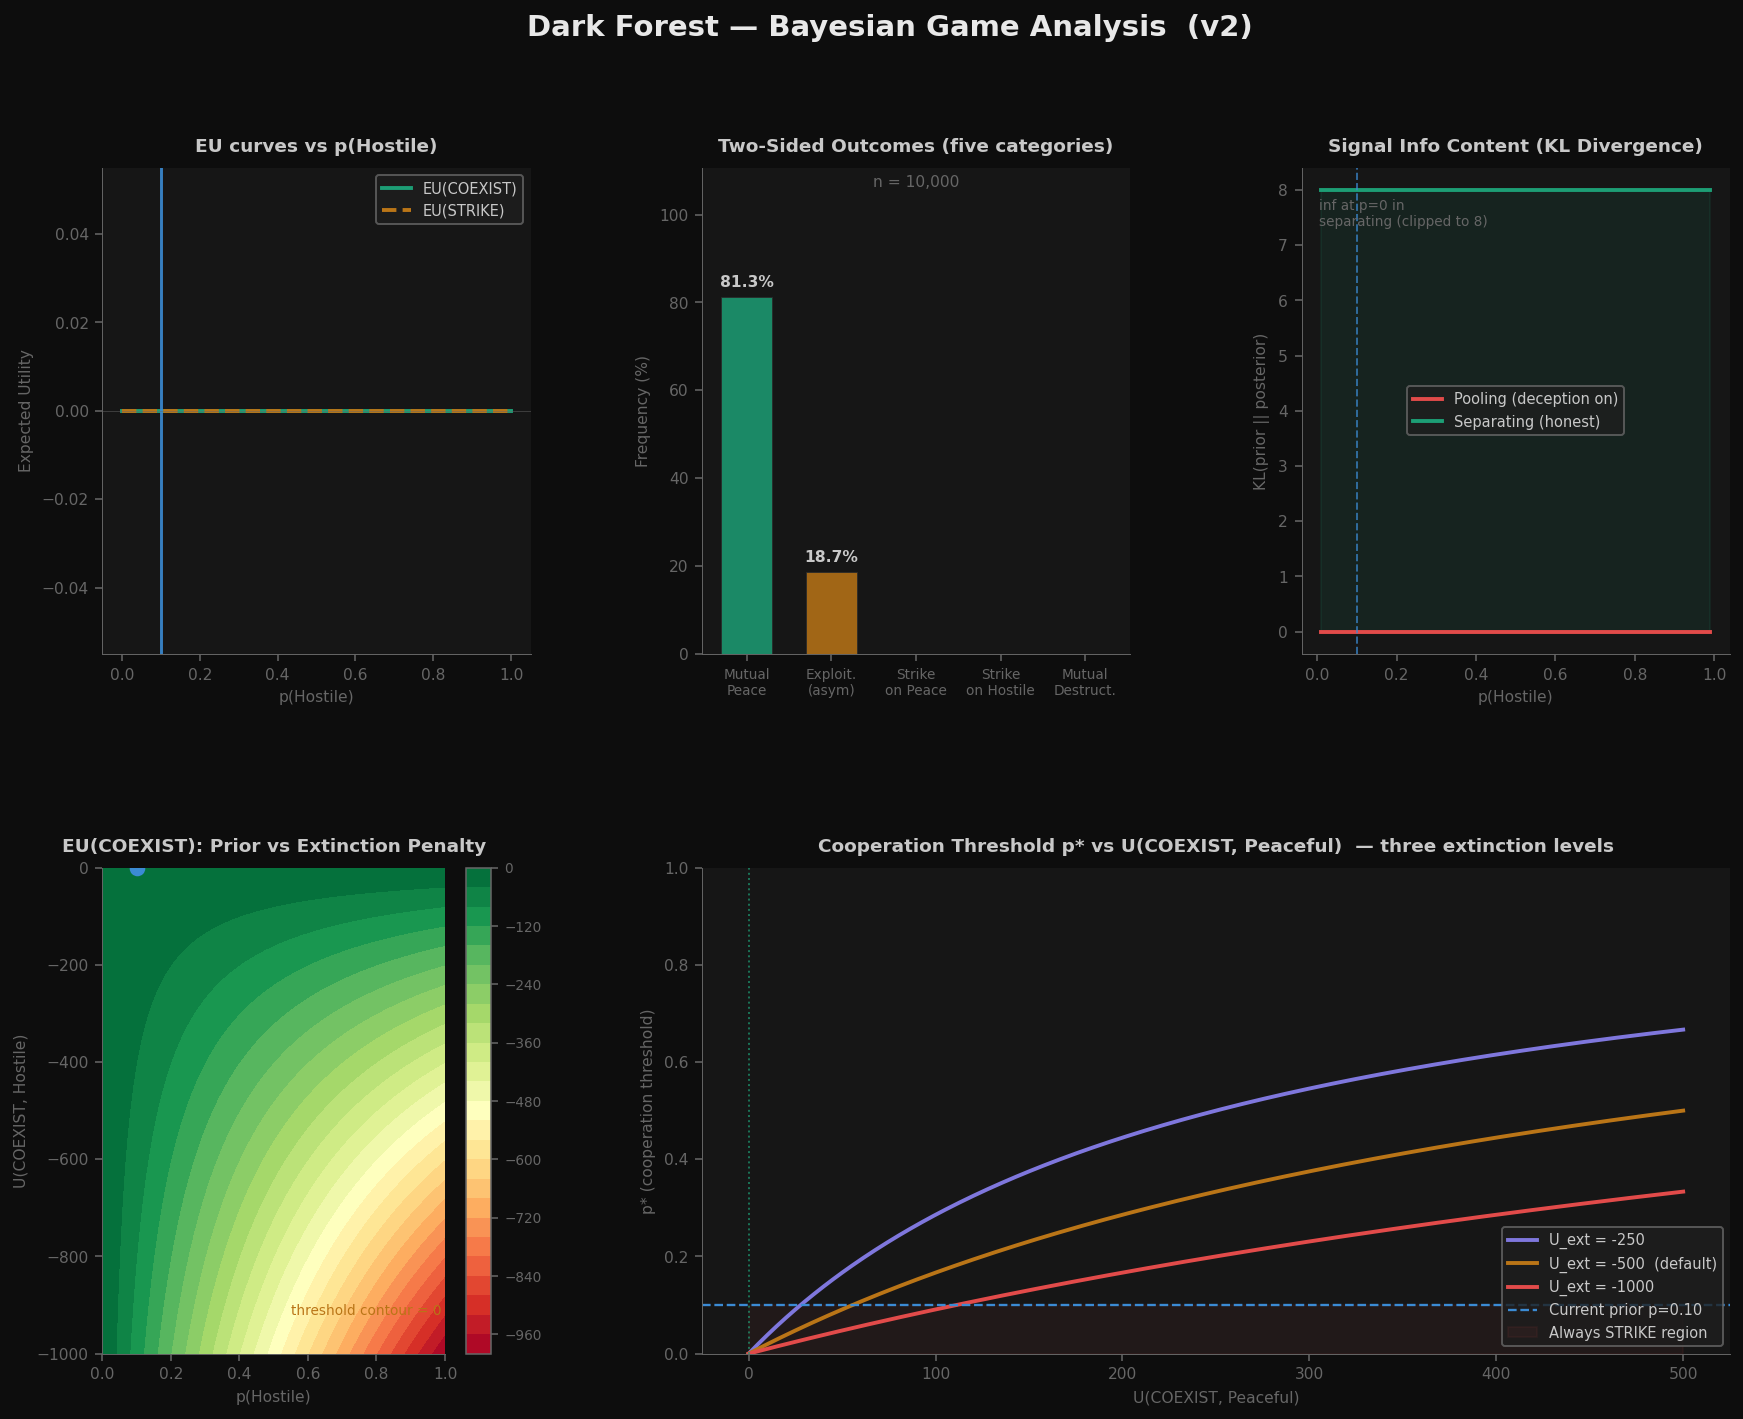

In [5]:
from IPython.display import Image, display

display(Image(filename='/mnt/user-data/outputs/dark_forest_analysis.png'))